# Summary

This AR-CNN is an autoregressive generative model, but its receptive field is limited.

Current setting:

```text
kernel_size = 3
n_cnn_layers = 2
effective receptive field = 5 positions on shifted input
```

Therefore each bit prediction can only use a limited local context, not the full prefix. Since 16-bit even parity is a global constraint, this model is expected to behave similarly to the local-window AR-MLP baseline.


## Experiment setting

In [1]:
# Imports and reproducibility
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import itertools

seed_val = 2
np.random.seed(seed_val)
torch.manual_seed(seed_val)

In [2]:
# Experiment setting
n_bits = 16

n_train = 16384 # 2000, 4096, 8192, 16384 - no ablation
n_test = 4096 # 2000, 4096, 4096, 4096 - no ablation

hidden_channels = 64
kernel_size = 3

n_cnn_layers = 6 # 2, 4, 6

# With no dilation, causal receptive field on shifted input:
receptive_field = 1 + (kernel_size - 1) * n_cnn_layers

epochs = 200
batch_size = 128
lr = 1e-3

In [3]:
# Generate all even-parity bitstrings
combinations = list(itertools.product([0, 1], repeat=n_bits)) # list of tuples
all_bitstrings = np.array(combinations, dtype=np.float32)

parity = all_bitstrings.sum(axis=1) % 2
even_bitstrings = all_bitstrings[parity == 0]

In [4]:
# Create train/test data
total_needed = n_train + n_test

idx = np.random.permutation(len(even_bitstrings))

train_idx = idx[:n_train]
test_idx = idx[n_train:n_train + n_test]

X_train = even_bitstrings[train_idx].astype(np.float32)
X_test = even_bitstrings[test_idx].astype(np.float32)

In [5]:
# Convert data to PyTorch tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)

## Shifted autoregressive input

The target is:

```text
[x1, x2, x3, ..., x16]
```

The CNN input is shifted:

```text
[0, x1, x2, ..., x15]
```

Then the output at position `i` is trained to predict `x_i`.
Because the convolution is causal, it cannot look at future bits.

In [6]:
# example
example_x = X_train_t[:3]

zero_col = torch.zeros(example_x.shape[0], 1) # add 0 to shift data to the right
example_shifted = torch.cat([zero_col, example_x[:, :-1]], dim=1) # shifted entire data

In [7]:
# Definition of masked causal CNN
class CausalCNN(nn.Module):
    def __init__(self, hidden_channels=64, kernel_size=3, n_cnn_layers=2):
        super().__init__()

        self.kernel_size = kernel_size

        self.convs = nn.ModuleList()

        self.convs.append(
            nn.Conv1d(
                in_channels=1,
                out_channels=hidden_channels,
                kernel_size=kernel_size
            )
        )

        for _ in range(n_cnn_layers - 1):
            self.convs.append(
                nn.Conv1d(
                    in_channels=hidden_channels,
                    out_channels=hidden_channels,
                    kernel_size=kernel_size
                )
            )

        self.output_conv = nn.Conv1d(
            in_channels=hidden_channels,
            out_channels=1,
            kernel_size=1
        )

    def forward(self, x):
        # x shape (batch_size, n_bits) -> h shape (batch_size, channel, n_bits)
        h = x.unsqueeze(1)

        for conv in self.convs:
            # causal left padding
            h = F.pad(h, (self.kernel_size - 1, 0)) # Need 0-initialized padding bit
            h = conv(h)
            h = F.relu(h)

        # receptive_field = 1 + (kernel_size - 1) * n_cnn_layers
        # Refering to the previous bits and generating the next bits
        logits = self.output_conv(h)

        # shape: batch_size x n_bits
        logits = logits.squeeze(1) # remove index 1 dim

        return logits

In [8]:
cnn_model = CausalCNN(
    hidden_channels=hidden_channels,
    kernel_size=kernel_size,
    n_cnn_layers=n_cnn_layers
)

print(cnn_model)

CausalCNN(
  (convs): ModuleList(
    (0): Conv1d(1, 64, kernel_size=(3,), stride=(1,))
    (1-5): 5 x Conv1d(64, 64, kernel_size=(3,), stride=(1,))
  )
  (output_conv): Conv1d(64, 1, kernel_size=(1,), stride=(1,))
)


In [9]:
optimizer = torch.optim.Adam(cnn_model.parameters(), lr=lr)

In [10]:
# example: quick forward-pass check
batch = X_train_t[:5]

zero_col = torch.zeros(batch.shape[0], 1)
batch_shifted = torch.cat([zero_col, batch[:, :-1]], dim=1)

logits = cnn_model(batch_shifted) # model output (batch, shape) logits

print("batch shape:", batch.shape)
print("shifted input shape:", batch_shifted.shape)
print("logits shape:", logits.shape)
print("First row logits:")
print(logits[0].detach().numpy())

batch shape: torch.Size([5, 16])
shifted input shape: torch.Size([5, 16])
logits shape: torch.Size([5, 16])
First row logits:
[0.05054548 0.04316938 0.0440353  0.04790814 0.04620353 0.04655562
 0.04571057 0.04495447 0.045233   0.04364422 0.04379592 0.04378001
 0.04440633 0.04469831 0.04292141 0.04332783]


In [11]:
# history placeholders for training AR-CNN
history = {
    "train_nll": [],
    "test_nll": []
}

In [12]:
# training loop
for epoch in range(epochs):

    cnn_model.train()

    # permute train data in each epoch
    perm = torch.randperm(len(X_train_t))
    total_train_loss = 0.0

    # mini-batch training
    for start_batch in range(0, len(X_train_t), batch_size):
        batch_idx = perm[start_batch:start_batch + batch_size]
        batch = X_train_t[batch_idx]

        zero_col = torch.zeros(batch.shape[0], 1)
        batch_shifted = torch.cat([zero_col, batch[:, :-1]], dim=1)

        logits = cnn_model(batch_shifted)

        bit_loss = F.binary_cross_entropy_with_logits( # compare logits and batch to compute loss
            logits,  # data with padding + shift -> logits
            batch, # original data without padding, shift
            reduction="none"
        )

        # avg. loss per batch
        loss = bit_loss.sum(dim=1).mean()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # total loss for entire train dataset
        total_train_loss += loss.item() * len(batch)

    train_nll = total_train_loss / len(X_train_t)
    history["train_nll"].append(train_nll)

    cnn_model.eval()

    with torch.no_grad():
        batch = X_test_t

        zero_col = torch.zeros(batch.shape[0], 1)
        batch_shifted = torch.cat([zero_col, batch[:, :-1]], dim=1)

        logits = cnn_model(batch_shifted)

        bit_loss = F.binary_cross_entropy_with_logits(
            logits,
            batch,
            reduction="none"
        )

        test_nll = bit_loss.sum(dim=1).mean().item()
        history["test_nll"].append(test_nll)

    if (epoch + 1) % 20 == 0:
        print(
            f"Epoch {epoch+1:4d} | "
            f"Train NLL: {train_nll:.4f} | "
            f"Test NLL: {test_nll:.4f}"
        )

Epoch   20 | Train NLL: 11.0906 | Test NLL: 11.0905
Epoch   40 | Train NLL: 11.0902 | Test NLL: 11.0910
Epoch   60 | Train NLL: 11.0895 | Test NLL: 11.0937
Epoch   80 | Train NLL: 11.0878 | Test NLL: 11.0978
Epoch  100 | Train NLL: 11.0842 | Test NLL: 11.1137
Epoch  120 | Train NLL: 11.0812 | Test NLL: 11.1194
Epoch  140 | Train NLL: 11.0774 | Test NLL: 11.1358
Epoch  160 | Train NLL: 11.0740 | Test NLL: 11.1356
Epoch  180 | Train NLL: 11.0710 | Test NLL: 11.1551
Epoch  200 | Train NLL: 11.0678 | Test NLL: 11.1680


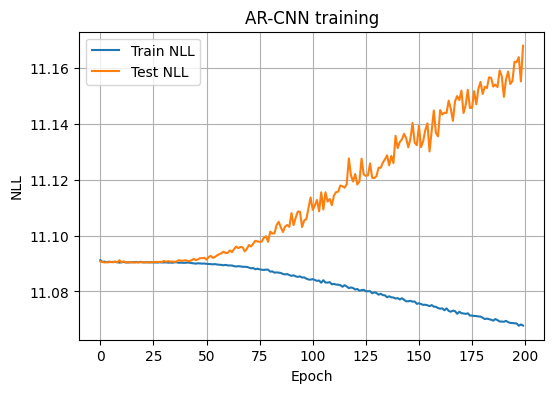

In [14]:
# Plotting NLL history
plt.figure(figsize=(6, 4))
plt.plot(history["train_nll"], label="Train NLL")
plt.plot(history["test_nll"], label="Test NLL")
plt.xlabel("Epoch")
plt.ylabel("NLL")
plt.title("AR-CNN training")
plt.legend()
plt.grid(True)
plt.show()

In [15]:
# Generation of samples from trained AR-CNN
cnn_model.eval()

n_generated = 5000

with torch.no_grad():
    generated_t = torch.zeros(n_generated, n_bits)

    for i in range(n_bits):

        zero_col = torch.zeros(n_generated, 1)
        shifted_input = torch.cat([zero_col, generated_t[:, :-1]], dim=1)

        logits = cnn_model(shifted_input)

        probs = torch.sigmoid(logits[:, i])

        generated_t[:, i] = torch.bernoulli(probs)

generated_cnn = generated_t.numpy().astype(np.int8)

print("Generated samples:", generated_cnn.shape)
print("First 10 generated samples:")
print(generated_cnn[:10])

Generated samples: (5000, 16)
First 10 generated samples:
[[0 0 0 0 0 1 0 1 1 0 0 1 0 1 1 1]
 [1 1 0 0 0 1 0 0 1 1 1 1 0 0 1 1]
 [1 0 1 0 0 1 1 0 0 0 1 0 0 0 0 0]
 [0 0 0 0 1 0 0 1 1 0 0 0 1 0 1 1]
 [1 0 1 1 1 1 0 0 0 1 1 1 1 0 1 0]
 [1 1 0 1 0 1 1 0 1 0 1 1 0 0 0 1]
 [0 0 1 0 1 1 1 1 0 1 1 1 0 1 1 0]
 [1 0 1 1 1 1 1 0 0 0 1 0 0 1 1 0]
 [1 0 0 0 1 1 0 1 1 0 1 1 1 1 1 0]
 [0 0 0 1 0 0 0 0 1 1 1 1 1 1 1 0]]


In [16]:
# Evaluation of generated samples

generated_parity = generated_cnn.sum(axis=1) % 2

odd_rate = generated_parity.mean()
parity_expectation = (1 - 2 * generated_parity).mean()

unique_generated = len(np.unique(generated_cnn, axis=0))

print("Generated samples:", len(generated_cnn))
print("Unique generated samples:", unique_generated)
print("Odd parity violation rate:", odd_rate)
print("Global parity expectation:", parity_expectation)

print("\nParity of first 10 generated samples:")
print(generated_parity[:10])

Generated samples: 5000
Unique generated samples: 4809
Odd parity violation rate: 0.5024
Global parity expectation: -0.0048

Parity of first 10 generated samples:
[1 1 1 0 0 1 0 1 0 0]


In [17]:
# Train/generated overlap diagnostic
gen_set = {tuple(x.astype(int)) for x in generated_cnn}
train_set = {tuple(x.astype(int)) for x in X_train.astype(int)}

overlap = gen_set.intersection(train_set)

overlap_rate = len(overlap) / len(gen_set) if len(gen_set) > 0 else 0.0
train_coverage = len(X_train) / len(even_bitstrings)

print("Train coverage in even support:", train_coverage)
print("Generated/train overlap rate:", overlap_rate)

Train coverage in even support: 0.5
Generated/train overlap rate: 0.2514036182158453


In [18]:
# KL evaluation

cnn_model.eval()

even_x = torch.tensor(even_bitstrings.astype(np.float32), dtype=torch.float32)

all_log_probs = []
kl_batch_size = 4096

with torch.no_grad():
    for start_batch in range(0, len(even_x), kl_batch_size):
        batch = even_x[start_batch:start_batch + kl_batch_size]

        zero_col = torch.zeros(batch.shape[0], 1)
        batch_shifted = torch.cat([zero_col, batch[:, :-1]], dim=1)

        logits = cnn_model(batch_shifted)

        log_prob_1 = F.logsigmoid(logits)
        log_prob_0 = F.logsigmoid(-logits)

        bit_log_probs = batch * log_prob_1 + (1 - batch) * log_prob_0

        log_prob = bit_log_probs.sum(dim=1)

        all_log_probs.append(log_prob.cpu())

log_p_model_even = torch.cat(all_log_probs).numpy()

log_p_true = -np.log(2 ** (n_bits - 1))

kl_cnn = np.mean(log_p_true - log_p_model_even)

print("Exact KL D_KL(p_even || p_model):", kl_cnn)
print("log 2:", np.log(2))

Exact KL D_KL(p_even || p_model): 0.7173754232252065
log 2: 0.6931471805599453


In [19]:
# Final result summary and JSON export

import json

result_summary = {
    "model": "AR-CNN",
    "objective": "NLL",
    "n_bits": int(n_bits),
    "n_train": int(n_train),
    "n_test": int(n_test),
    "hidden_channels": int(hidden_channels),
    "kernel_size": int(kernel_size),
    "n_cnn_layers": int(n_cnn_layers),
    "receptive_field": int(receptive_field),
    "epochs": int(epochs),
    "batch_size": int(batch_size),
    "learning_rate": float(lr),
    "generated_samples": int(len(generated_cnn)),
    "unique_generated_samples": int(len(np.unique(generated_cnn, axis=0))),
    "odd_rate": float(odd_rate),
    "parity_expectation": float(parity_expectation),
    "kl": float(kl_cnn)
}

print(result_summary)

file_name = f"ar_cnn_seed{seed_val}_rf{receptive_field}_layers{n_cnn_layers}_result.json"

with open(file_name, "w") as f:
    json.dump(result_summary, f, indent=4)

print("Saved:", file_name)

{'model': 'AR-CNN', 'objective': 'NLL', 'n_bits': 16, 'n_train': 16384, 'n_test': 4096, 'hidden_channels': 64, 'kernel_size': 3, 'n_cnn_layers': 6, 'receptive_field': 13, 'epochs': 200, 'batch_size': 128, 'learning_rate': 0.001, 'generated_samples': 5000, 'unique_generated_samples': 4809, 'odd_rate': 0.5024, 'parity_expectation': -0.0048, 'kl': 0.7173754232252065}
Saved: ar_cnn_seed2_rf13_layers6_result.json
